# Resampling ablation: sensitivity to rho and B

This notebook reads one run of the `rho_b` ablation and shows every summary the
SI figures and table are built from. It computes nothing: produce a run with

```
python -m benchmarks.run --ablation rho_b
```

from `code/`. The rho arm sweeps the subsampling
proportion at the default resample count; the B arm sweeps the resample count
at the default proportion. Which scenarios, difficulties and datasets the
arms cover is set in the registry (`ABLATIONS["rho_b"]`); it currently runs the
medium gaussians setting only, with no case study.

In [1]:
%matplotlib inline

## 1) Setup

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from benchmarks._ablation_cells import REFERENCE_RATIO, arm_view, enumerate_cells
from benchmarks._ablation_summary import (
    HEADLINE_METRICS,
    POOLED,
    agreement_summary,
    ari_summary,
    bias_summary,
    curve_at_k_star,
    diagnostics_summary,
    rare_recall_summary,
    similarity_at_k_star,
    similarity_summary,
    spread_summary,
    table_rows,
)
from benchmarks._artifacts import read_frames
from benchmarks._registry import ABLATIONS, METRIC_DISPLAY_NAMES
from benchmarks._tables import write_ablation_table
from benchmarks._theme import theme_context
from benchmarks.figures import figure_ablation, figure_ablation_resampling
from benchmarks.figures._paths import REPO_ROOT

ABLATION = ABLATIONS["rho_b"]
SCALE = ABLATION.default_scale
STUDY = ABLATION.study
RHO, B = "subsample_ratio", "n_resamples"

runs = sorted((REPO_ROOT / "results" / "runs" / f"ablation_{ABLATION.name}" / SCALE).glob("*/manifest.json"))
if not runs:
    raise FileNotFoundError(f"No {SCALE} run of ablation {ABLATION.name}; run python -m benchmarks.run --ablation {ABLATION.name}")
RUN_DIR = runs[-1].parent
frames = read_frames(RUN_DIR)
rho_view = arm_view(frames, ablation=ABLATION, scale=SCALE, arm="rho")
b_view = arm_view(frames, ablation=ABLATION, scale=SCALE, arm="b")
print(RUN_DIR)
print({name: len(frame) for name, frame in frames.items()})
print("cells expected:", len(enumerate_cells(ABLATION, SCALE)), "recorded:", len(frames["cells"]))

/Users/kaiwycik/GitHub/CARVE/code/.claude/worktrees/ablation-ari-figure/results/runs/ablation_rho_b/publication/84a45382c2ce
{'curves': 19500, 'selection': 3900, 'at_k': 3000, 'cells': 300, 'datasets': 20, 'similarity': 18000}
cells expected: 300 recorded: 300


In [3]:
import json

manifest = json.loads((RUN_DIR / "manifest.json").read_text())
pd.Series({k: manifest[k] for k in ("run_id", "status", "scale", "config_hash", "workers", "thread_cap", "cores", "n_units", "wall_clock_s", "git_sha")})

run_id                                      7db99b716587
status                                          complete
scale                                        publication
config_hash                                 84a45382c2ce
workers                                               11
thread_cap                                             1
cores                                                 11
n_units                                              500
wall_clock_s                                22130.760934
git_sha         babd30623ddd7d1f78b36342ba60d82c137f7da3
dtype: object

## 2) Rho arm, simulations

Each plot below draws one line per scenario and the pooled line over all
simulated cells, against the subsampling proportion, for the two headline
selectors. Rare-cluster recall is read at the rho arm's last difficulty.

In [4]:
def lines(ax, summary, *, x, y, metric, lo=None, hi=None, title=None, y_label=None):
    rows = summary[summary["metric_name"] == metric]
    for study, part in rows.groupby("study"):
        part = part.sort_values(x)
        if study == POOLED:
            ax.plot(part[x], part[y], color="black", linewidth=2, marker="o", label="pooled")
            if lo is not None:
                ax.fill_between(part[x], part[lo], part[hi], color="black", alpha=0.1)
        else:
            ax.plot(part[x], part[y], marker="o", markersize=3, alpha=0.7, label=study)
    ax.set_xlabel(x)
    ax.set_ylabel(y_label or y)
    ax.set_title(title or METRIC_DISPLAY_NAMES.get(metric, metric))


def pair(summary, *, x, y, lo=None, hi=None, y_label=None, logx=False):
    with theme_context():
        fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
        for ax, metric in zip(axes, HEADLINE_METRICS):
            lines(ax, summary, x=x, y=y, metric=metric, lo=lo, hi=hi, y_label=y_label)
            if logx:
                ax.set_xscale("log")
        axes[0].legend(fontsize=7)
        fig.tight_layout()
    return fig

,subsample_ratio,study,metric_name,ari_mean,ari_sem,n_datasets
16,0.200,pooled,ari_generalizability_1se,0.714509,0.020705,20
17,0.200,pooled,ari_stability_1se,0.793383,0.016782,20
18,0.300,pooled,ari_generalizability_1se,0.732740,0.018361,20
19,0.300,pooled,ari_stability_1se,0.816992,0.017985,20
20,0.400,pooled,ari_generalizability_1se,0.732110,0.018149,20
21,0.400,pooled,ari_stability_1se,0.813133,0.017485,20
22,0.500,pooled,ari_generalizability_1se,0.736834,0.018201,20
23,0.500,pooled,ari_stability_1se,0.822343,0.016925,20
24,0.618,pooled,ari_generalizability_1se,0.721622,0.016588,20
25,0.618,pooled,ari_stability_1se,0.820430,0.016183,20


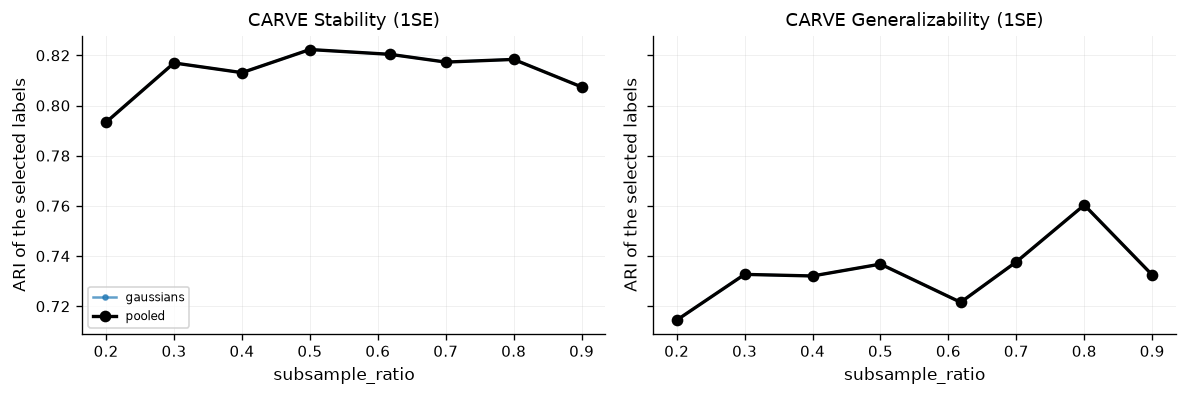

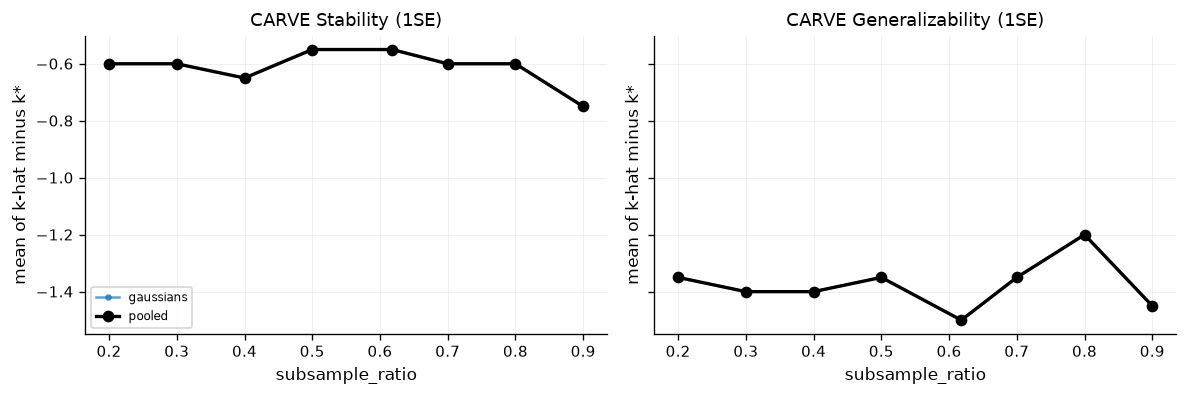

In [5]:
rho_ari = ari_summary(rho_view["selection"], rho_view["at_k"], x=RHO)
pair(rho_ari, x=RHO, y="ari_mean", y_label="ARI of the selected labels")
rho_bias = bias_summary(rho_view["selection"], x=RHO)
pair(rho_bias, x=RHO, y="bias_mean", y_label="mean of k-hat minus k*")
rho_ari[rho_ari["study"] == POOLED]

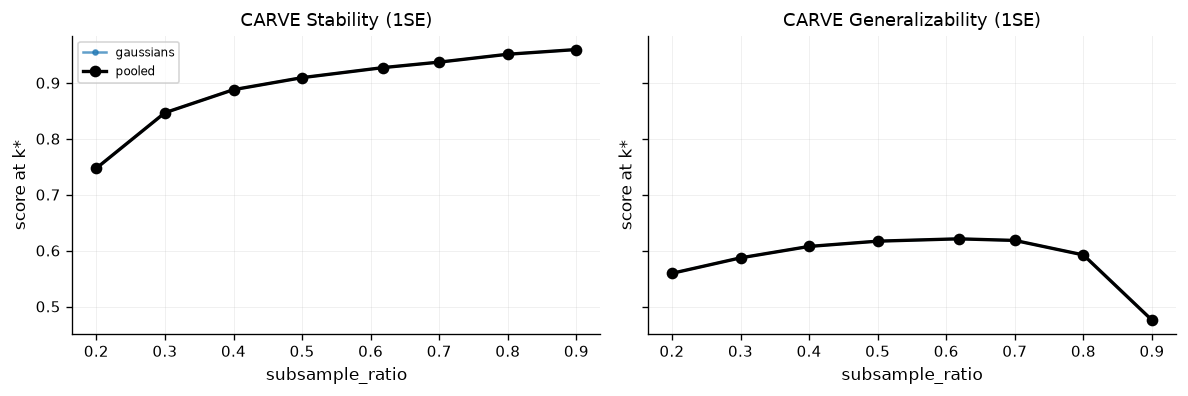

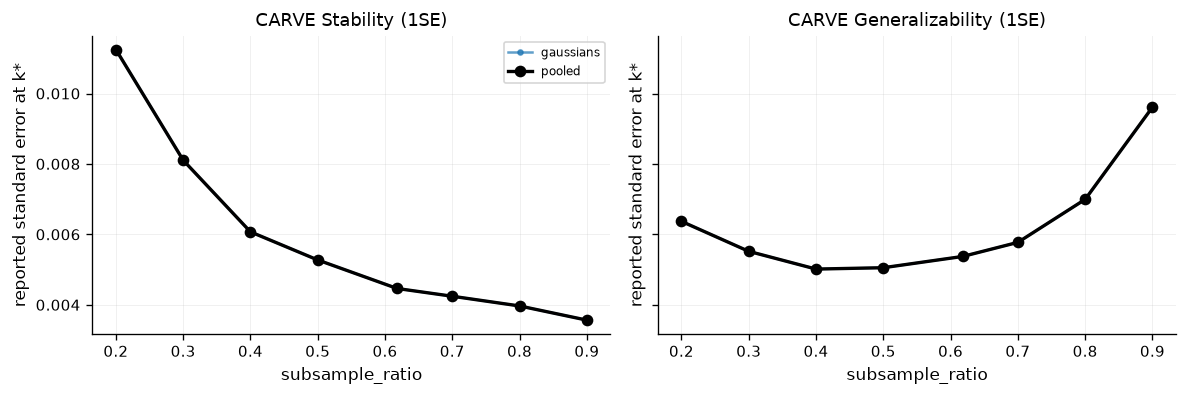

In [6]:
rho_star = curve_at_k_star(rho_view["curves"], rho_view["datasets"], x=RHO)
pair(rho_star, x=RHO, y="value_mean", y_label="score at k*")
pair(rho_star, x=RHO, y="se_mean", y_label="reported standard error at k*");

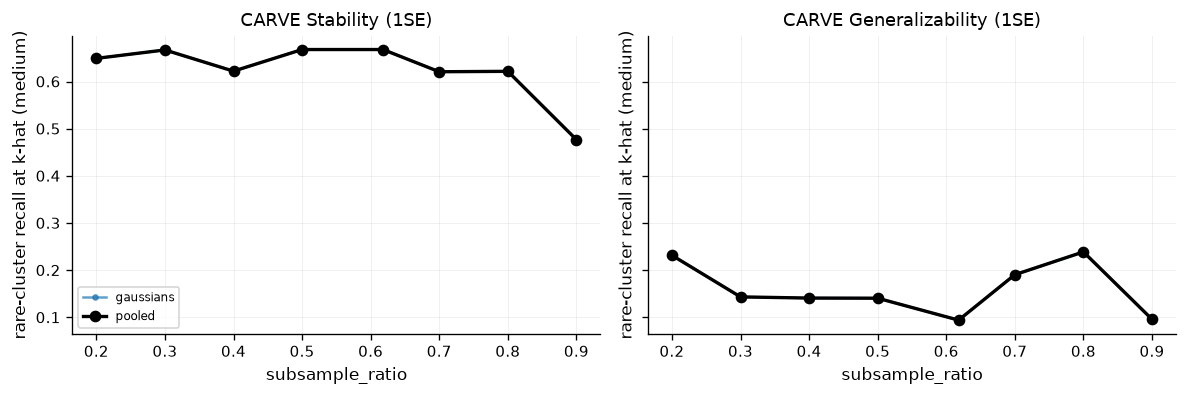

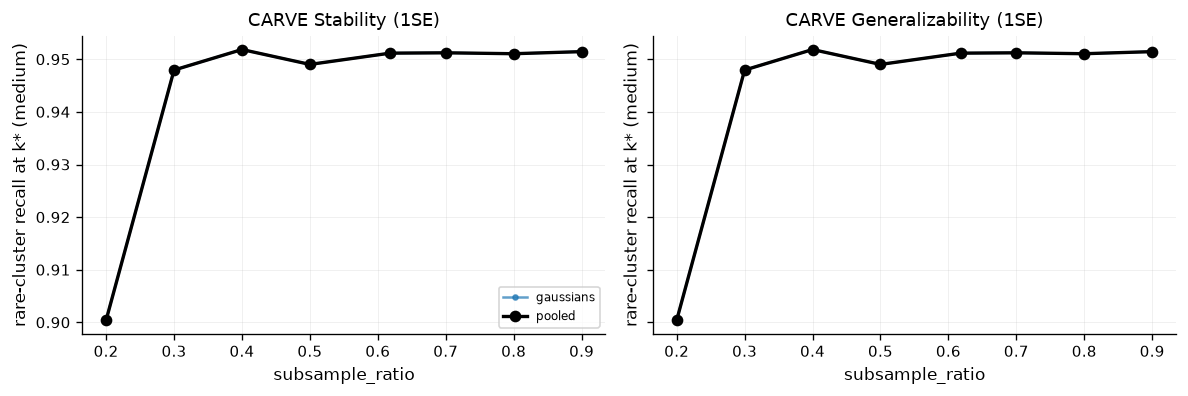

In [7]:
rare_difficulty = ABLATION.scales[SCALE].rho_arm.difficulties[-1]
rho_recall = rare_recall_summary(rho_view["at_k"], rho_view["selection"], x=RHO, difficulty=rare_difficulty)
pair(rho_recall, x=RHO, y="recall_selected", y_label=f"rare-cluster recall at k-hat ({rare_difficulty})")
pair(rho_recall, x=RHO, y="recall_k_star", y_label=f"rare-cluster recall at k* ({rare_difficulty})");

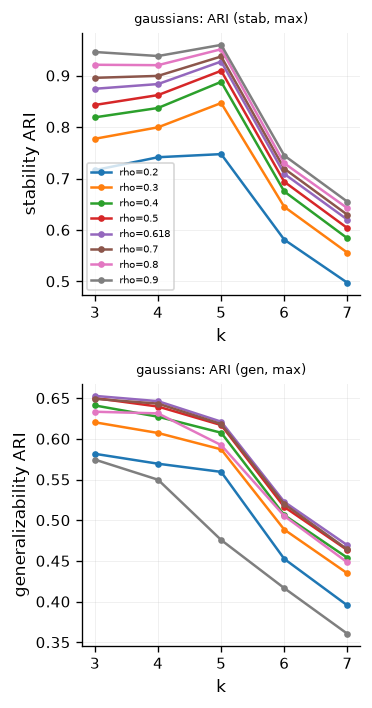

In [8]:
# Score curves over k at every rho, per scenario, for the stability selector.
curves = rho_view["curves"]
sims = curves[curves["difficulty"] != ""]
with theme_context():
    scenarios = list(ABLATION.scenarios)
    fig, axes = plt.subplots(2, len(scenarios), figsize=(3.2 * len(scenarios), 6), sharey="row", squeeze=False)
    for row, metric in enumerate(("ari_stability", "ari_generalizability")):
        for col, name in enumerate(scenarios):
            ax = axes[row, col]
            part = sims[(sims["study"] == name) & (sims["metric_name"] == metric)]
            for rho, group in part.groupby(RHO):
                mean = group.groupby("k")["metric_value"].mean()
                ax.plot(mean.index, mean.values, marker="o", markersize=3, label=f"rho={rho:g}")
            ax.set_title(f"{name}: {METRIC_DISPLAY_NAMES.get(metric, metric)}", fontsize=8)
            ax.set_xlabel("k")
    axes[0, 0].set_ylabel("stability ARI")
    axes[1, 0].set_ylabel("generalizability ARI")
    axes[0, -1].legend(fontsize=6)
    fig.tight_layout()

## 3) B arm

,n_resamples,study,metric_name,ari_mean,ari_sem,n_datasets
10,10,pooled,ari_generalizability_1se,0.752326,0.015715,10
11,10,pooled,ari_stability_1se,0.834545,0.017596,10
12,25,pooled,ari_generalizability_1se,0.735654,0.015088,10
13,25,pooled,ari_stability_1se,0.822488,0.022058,10
14,50,pooled,ari_generalizability_1se,0.729504,0.016976,10
15,50,pooled,ari_stability_1se,0.824145,0.021273,10
16,100,pooled,ari_generalizability_1se,0.730239,0.015354,10
17,100,pooled,ari_stability_1se,0.816516,0.021991,10
18,200,pooled,ari_generalizability_1se,0.731033,0.015177,10
19,200,pooled,ari_stability_1se,0.824218,0.021749,10


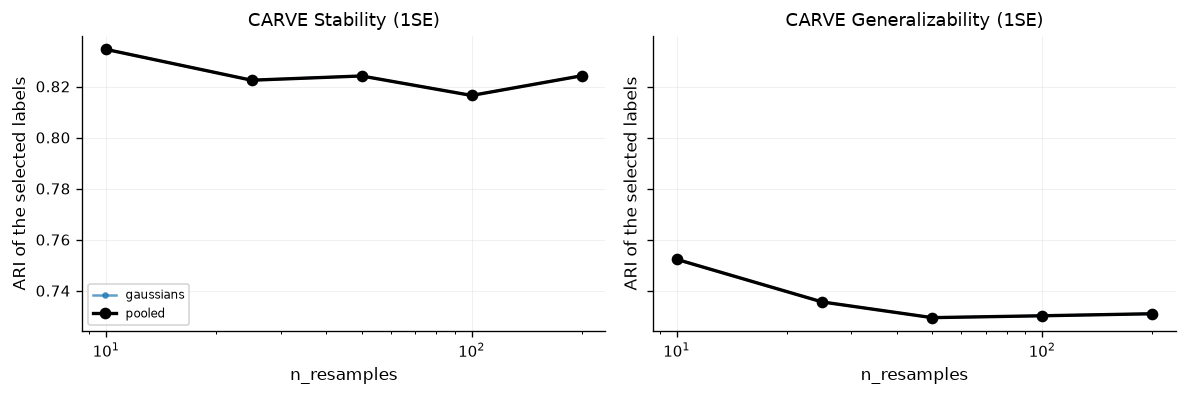

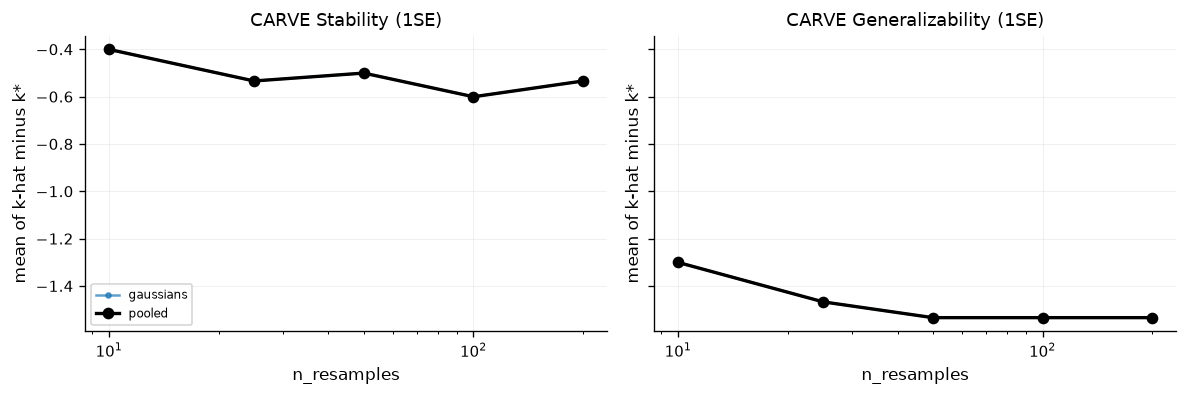

In [9]:
b_ari = ari_summary(b_view["selection"], b_view["at_k"], x=B)
pair(b_ari, x=B, y="ari_mean", y_label="ARI of the selected labels", logx=True)
b_bias = bias_summary(b_view["selection"], x=B)
pair(b_bias, x=B, y="bias_mean", y_label="mean of k-hat minus k*", logx=True)
b_ari[b_ari["study"] == POOLED]

,n_resamples,study,metric_name,agreement,n_datasets
10,10,pooled,ari_generalizability_1se,0.700000,10
11,10,pooled,ari_stability_1se,0.800000,10
12,25,pooled,ari_generalizability_1se,0.866667,10
13,25,pooled,ari_stability_1se,0.933333,10
14,50,pooled,ari_generalizability_1se,0.933333,10
15,50,pooled,ari_stability_1se,0.866667,10
16,100,pooled,ari_generalizability_1se,0.866667,10
17,100,pooled,ari_stability_1se,0.900000,10
18,200,pooled,ari_generalizability_1se,0.866667,10
19,200,pooled,ari_stability_1se,0.933333,10


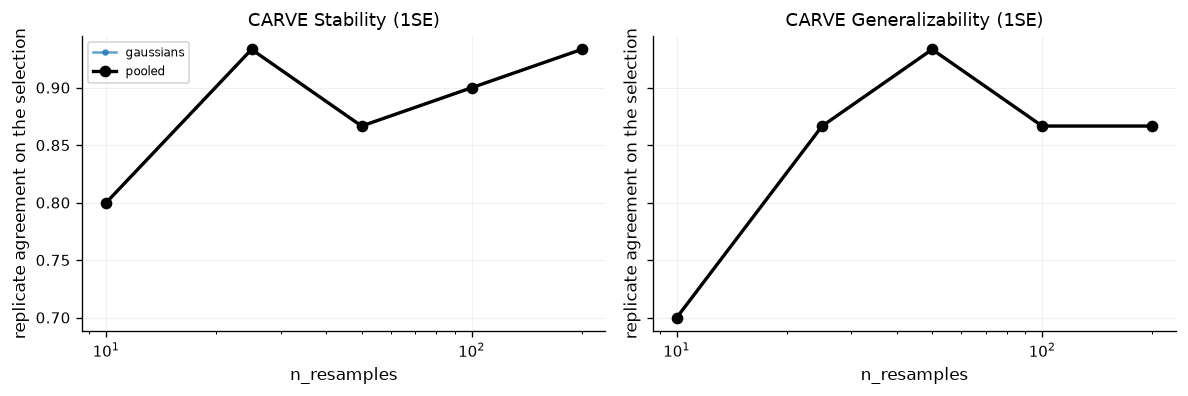

In [10]:
b_agree = agreement_summary(b_view["selection"], x=B)
pair(b_agree, x=B, y="agreement", y_label="replicate agreement on the selection", logx=True)
b_agree[b_agree["study"] == POOLED]

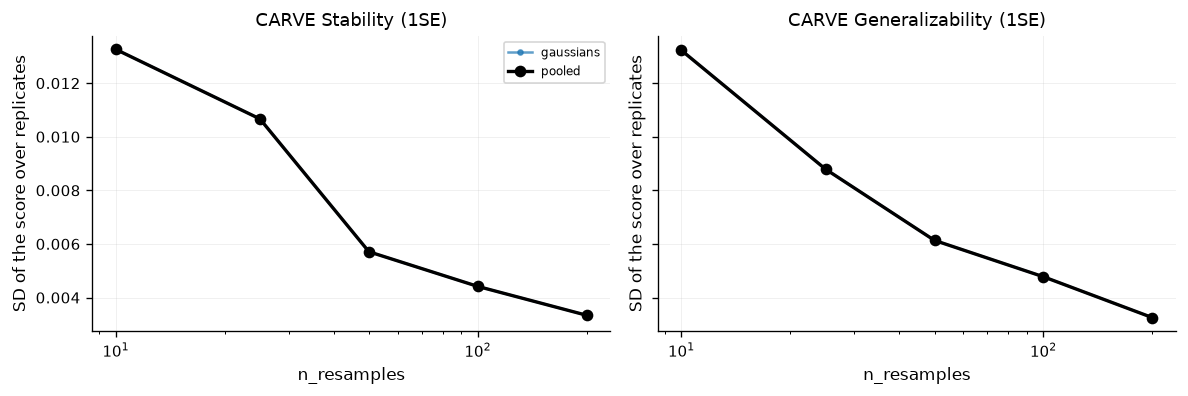

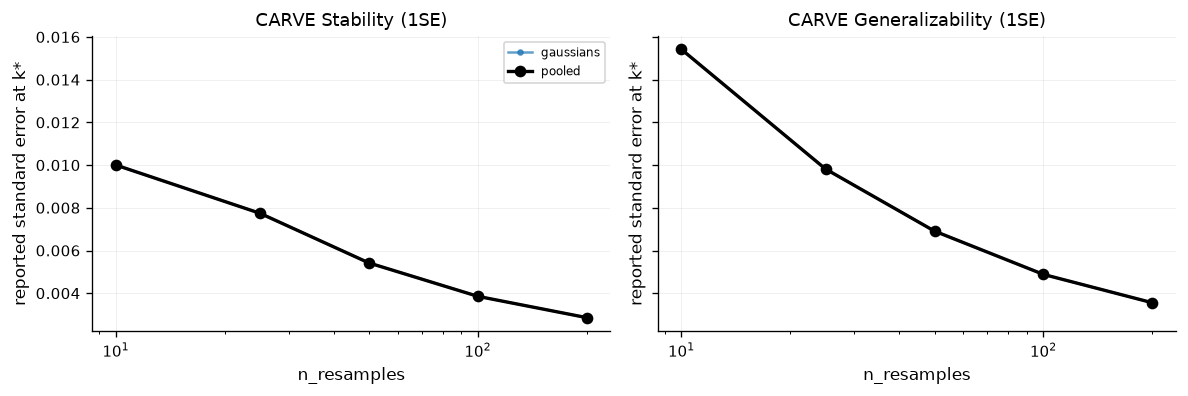

In [11]:
b_spread = spread_summary(b_view["curves"], x=B)
pair(b_spread, x=B, y="spread", y_label="SD of the score over replicates", logx=True)
b_star = curve_at_k_star(b_view["curves"], b_view["datasets"], x=B)
pair(b_star, x=B, y="se_mean", y_label="reported standard error at k*", logx=True);

## 4) Subsample versus full-data similarity

ARI between a clustering of a subsample and the full-data clustering
restricted to that subsample, per scenario and candidate k. The point at
ratio 1 is the refit reference: the full data clustered again with another
seed, which separates the estimator's own randomness from subsampling.

,subsample_ratio,study,ari_mean,ari_sem,n_datasets
0,0.200,gaussians,0.832980,0.016641,20
1,0.300,gaussians,0.889699,0.012450,20
2,0.400,gaussians,0.921385,0.007666,20
3,0.500,gaussians,0.934393,0.007407,20
4,0.618,gaussians,0.945737,0.006412,20
5,0.700,gaussians,0.956738,0.005150,20
6,0.800,gaussians,0.966873,0.003453,20
7,0.900,gaussians,0.967333,0.007351,20
8,1.000,gaussians,0.977140,0.004489,20
9,0.200,pooled,0.832980,0.016641,20


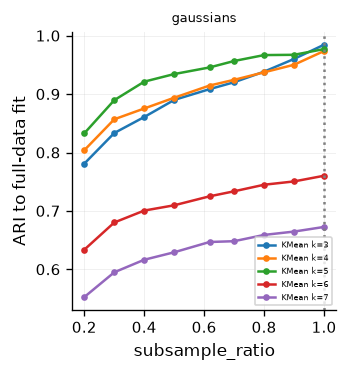

In [12]:
sim = similarity_summary(rho_view["similarity"])
with theme_context():
    studies = list(ABLATION.scenarios)
    fig, axes = plt.subplots(1, len(studies), figsize=(3.0 * len(studies), 3.2), sharey=True, squeeze=False)
    axes = axes[0]
    for ax, name in zip(axes, studies):
        part = sim[sim["study"] == name]
        for (estimator, k), group in part.groupby(["estimator", "k"]):
            group = group.sort_values(RHO)
            ax.plot(group[RHO], group["ari_mean"], marker="o", markersize=3, label=f"{estimator[:5]} k={k}")
        ax.axvline(REFERENCE_RATIO, color="grey", linestyle=":")
        ax.set_title(name, fontsize=8); ax.set_xlabel(RHO)
    axes[0].set_ylabel("ARI to full-data fit"); axes[-1].legend(fontsize=5)
    fig.tight_layout()
similarity_at_k_star(rho_view["similarity"], rho_view["datasets"])

## 5) Diagnostics

Per setting and study: mean fit time, the largest fraction of never-co-sampled
entries in the stability consensus (training pairs) and in the generalizability
consensus (test-set pairs; sparser at the grid ends), and the mean count of
cluster-count warnings.

,subsample_ratio,study,fit_seconds,consensus_nan_fraction,consensus_generalizability_nan_fraction,n_cluster_count_warnings,arm,n_resamples
0,0.200,gaussians,362.233471,0.016593,0.000000e+00,0.0,rho,NaN
1,0.300,gaussians,487.998901,0.000067,0.000000e+00,0.0,rho,NaN
2,0.400,gaussians,625.668070,0.000000,0.000000e+00,0.0,rho,NaN
3,0.500,gaussians,765.221746,0.000000,0.000000e+00,0.0,rho,NaN
4,0.618,gaussians,936.419882,0.000000,0.000000e+00,0.0,rho,NaN
5,0.700,gaussians,1062.294900,0.000000,8.720000e-05,0.0,rho,NaN
6,0.800,gaussians,1216.729558,0.000000,1.744378e-02,0.0,rho,NaN
7,0.900,gaussians,1367.554966,0.000000,3.681113e-01,0.0,rho,NaN
0,NaN,gaussians,94.698549,0.007801,2.077684e-01,0.0,b,10.0
1,NaN,gaussians,236.637786,0.000005,1.886095e-02,0.0,b,25.0


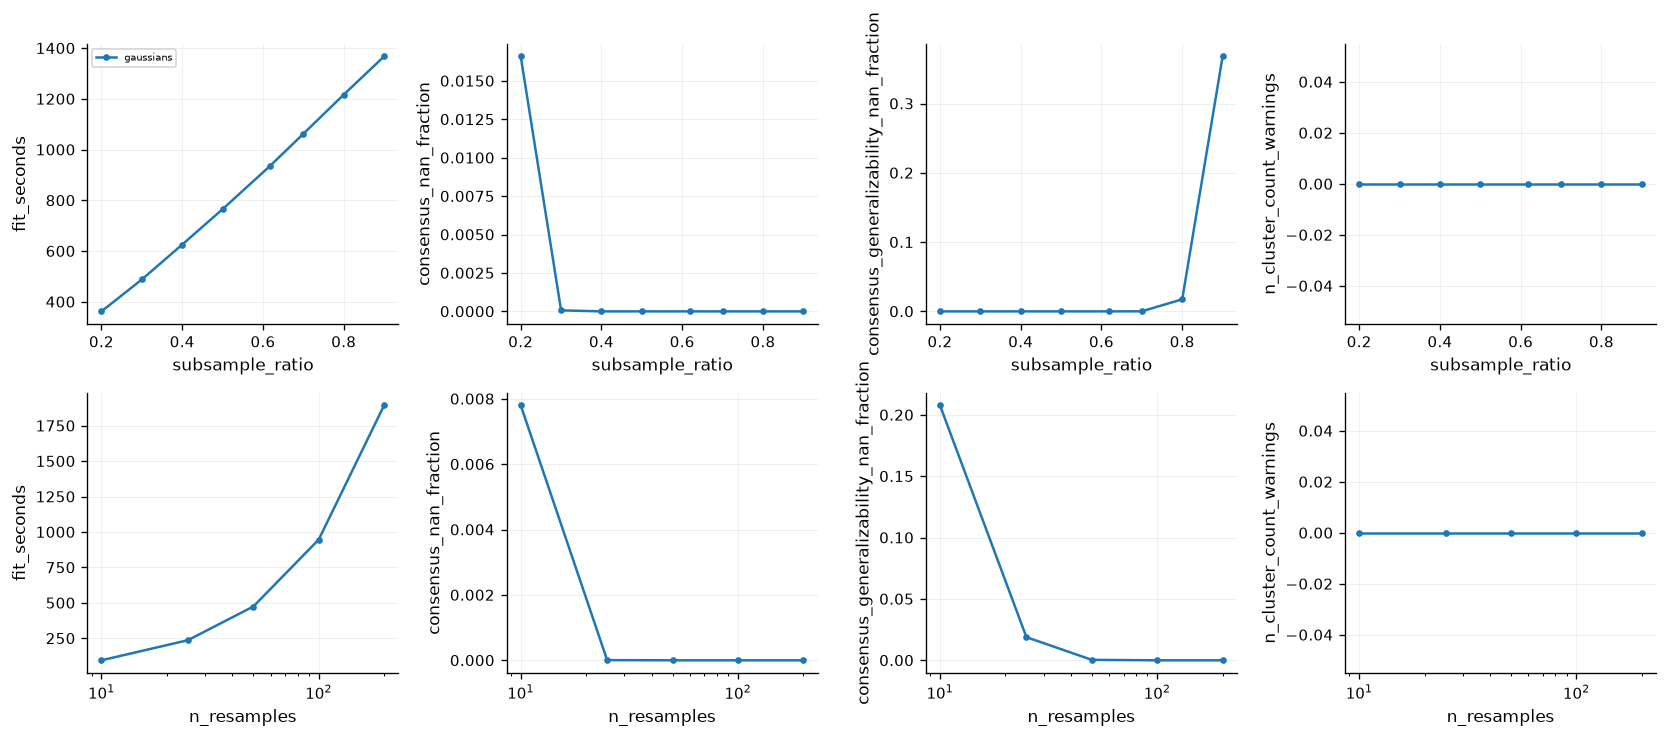

In [13]:
diag_rho = diagnostics_summary(rho_view["cells"], x=RHO)
diag_b = diagnostics_summary(b_view["cells"], x=B)
with theme_context():
    fig, axes = plt.subplots(2, 4, figsize=(14, 6))
    for row, (diag, x) in enumerate(((diag_rho, RHO), (diag_b, B))):
        for col, y in enumerate((
            "fit_seconds",
            "consensus_nan_fraction",
            "consensus_generalizability_nan_fraction",
            "n_cluster_count_warnings",
        )):
            ax = axes[row, col]
            for study, part in diag.groupby("study"):
                part = part.sort_values(x)
                ax.plot(part[x], part[y], marker="o", markersize=3, label=study)
            ax.set_xlabel(x); ax.set_ylabel(y)
            if x == B:
                ax.set_xscale("log")
    axes[0, 0].legend(fontsize=6)
    fig.tight_layout()
pd.concat([diag_rho.assign(arm="rho"), diag_b.assign(arm="b")])

## 6) SI figures and table

Written under `vis/benchmarking/` and `results/tables/`; copying into the
manuscript stays a manual step.

findfont: Failed to find font weight normal, now using 0.


\begin{table}[ht]
\centering
\caption{Sensitivity of CARVE's selections to the subsampling proportion and the resample count.}
\label{tab:ablation_rho_b}
\begin{tabular}{lcc}
\hline
 & \multicolumn{1}{c}{CARVE Stability (1SE)} & \multicolumn{1}{c}{CARVE Generalizability (1SE)} \\
$\rho$ & ARI & ARI \\
\hline
0.2 & 0.793 & 0.715 \\
0.3 & 0.817 & 0.733 \\
0.4 & 0.813 & 0.732 \\
0.5 & 0.822 & 0.737 \\
0.618 & 0.820 & 0.722 \\
0.7 & 0.817 & 0.738 \\
0.8 & 0.818 & 0.760 \\
0.9 & 0.807 & 0.733 \\
\hline
\end{tabular}
\vspace{1em}
\begin{tabular}{lcccc}
\hline
 & \multicolumn{2}{c}{CARVE Stability (1SE)} & \multicolumn{2}{c}{CARVE Generalizability (1SE)} \\
$B$ & ARI & Agreement & ARI & Agreement \\
\hline
10 & 0.835 & 0.80 & 0.752 & 0.70 \\
25 & 0.822 & 0.93 & 0.736 & 0.87 \\
50 & 0.824 & 0.87 & 0.730 & 0.93 \\
100 & 0.817 & 0.90 & 0.730 & 0.87 \\
200 & 0.824 & 0.93 & 0.731 & 0.87 \\
\hline
\end{tabular}
\end{table}



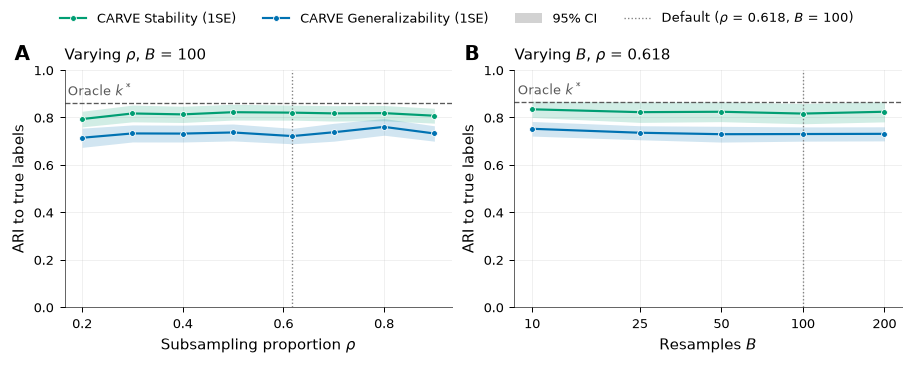

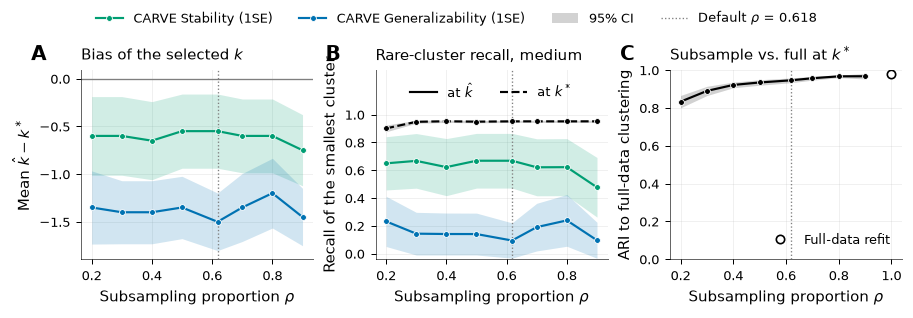

In [14]:
figure_ablation(frames, ablation=ABLATION, scale=SCALE)
figure_ablation_resampling(frames, ablation=ABLATION, scale=SCALE)
table_path = write_ablation_table(frames, ablation=ABLATION, scale=SCALE, out_dir=REPO_ROOT / "results" / "tables")
print(table_path.read_text())

In [15]:
table_rows(rho_view, x=RHO, study=STUDY)

,setting,metric_name,ari_mean,agreement,study_modal,study_share
0,0.200,ari_generalizability_1se,0.714509,NaN,NaN,NaN
1,0.200,ari_stability_1se,0.793383,NaN,NaN,NaN
2,0.300,ari_generalizability_1se,0.732740,NaN,NaN,NaN
3,0.300,ari_stability_1se,0.816992,NaN,NaN,NaN
4,0.400,ari_generalizability_1se,0.732110,NaN,NaN,NaN
5,0.400,ari_stability_1se,0.813133,NaN,NaN,NaN
6,0.500,ari_generalizability_1se,0.736834,NaN,NaN,NaN
7,0.500,ari_stability_1se,0.822343,NaN,NaN,NaN
8,0.618,ari_generalizability_1se,0.721622,NaN,NaN,NaN
9,0.618,ari_stability_1se,0.820430,NaN,NaN,NaN


In [16]:
table_rows(b_view, x=B, study=STUDY)

,setting,metric_name,ari_mean,agreement,study_modal,study_share
0,10,ari_generalizability_1se,0.752326,0.700000,NaN,NaN
1,10,ari_stability_1se,0.834545,0.800000,NaN,NaN
2,25,ari_generalizability_1se,0.735654,0.866667,NaN,NaN
3,25,ari_stability_1se,0.822488,0.933333,NaN,NaN
4,50,ari_generalizability_1se,0.729504,0.933333,NaN,NaN
5,50,ari_stability_1se,0.824145,0.866667,NaN,NaN
6,100,ari_generalizability_1se,0.730239,0.866667,NaN,NaN
7,100,ari_stability_1se,0.816516,0.900000,NaN,NaN
8,200,ari_generalizability_1se,0.731033,0.866667,NaN,NaN
9,200,ari_stability_1se,0.824218,0.933333,NaN,NaN
